In [14]:
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
cases = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv')
deaths = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_US.csv')

In [16]:
print (cases.head())
print (deaths.head())

        UID iso2 iso3  code3    FIPS   Admin2 Province_State Country_Region  \
0  84001001   US  USA    840  1001.0  Autauga        Alabama             US   
1  84001003   US  USA    840  1003.0  Baldwin        Alabama             US   
2  84001005   US  USA    840  1005.0  Barbour        Alabama             US   
3  84001007   US  USA    840  1007.0     Bibb        Alabama             US   
4  84001009   US  USA    840  1009.0   Blount        Alabama             US   

         Lat      Long_  ... 2/28/23  3/1/23  3/2/23  3/3/23  3/4/23  3/5/23  \
0  32.539527 -86.644082  ...   19732   19759   19759   19759   19759   19759   
1  30.727750 -87.722071  ...   69641   69767   69767   69767   69767   69767   
2  31.868263 -85.387129  ...    7451    7474    7474    7474    7474    7474   
3  32.996421 -87.125115  ...    8067    8087    8087    8087    8087    8087   
4  33.982109 -86.567906  ...   18616   18673   18673   18673   18673   18673   

   3/6/23  3/7/23  3/8/23  3/9/23  
0   1975

In [17]:
cases_ca = cases[cases["Province_State"] == "California"]

In [18]:
cases_idx= cases_ca.set_index("Admin2")

In [19]:
cases_t=cases_idx.T

In [20]:
print(cases_idx.head())
print(cases_t.head())

                UID iso2 iso3  code3    FIPS Province_State Country_Region  \
Admin2                                                                       
Alameda    84006001   US  USA    840  6001.0     California             US   
Alpine     84006003   US  USA    840  6003.0     California             US   
Amador     84006005   US  USA    840  6005.0     California             US   
Butte      84006007   US  USA    840  6007.0     California             US   
Calaveras  84006009   US  USA    840  6009.0     California             US   

                 Lat       Long_               Combined_Key  ...  2/28/23  \
Admin2                                                       ...            
Alameda    37.646294 -121.892927    Alameda, California, US  ...   401161   
Alpine     38.596786 -119.822359     Alpine, California, US  ...      143   
Amador     38.445831 -120.656960     Amador, California, US  ...    11540   
Butte      39.667278 -121.600525      Butte, California, US  ...    

In [21]:
cases_clean = cases_t.drop(['UID','iso2','iso3','code3','FIPS','Province_State','Country_Region','Lat','Long_','Combined_Key'])
deaths_clean = deaths[deaths["Province_State"] == "California"].set_index("Admin2").T.drop(['UID','iso2','iso3','code3','FIPS','Province_State','Country_Region','Lat','Long_','Combined_Key']).drop("Population",axis=0)

Text(0.5, 1.0, 'cases')

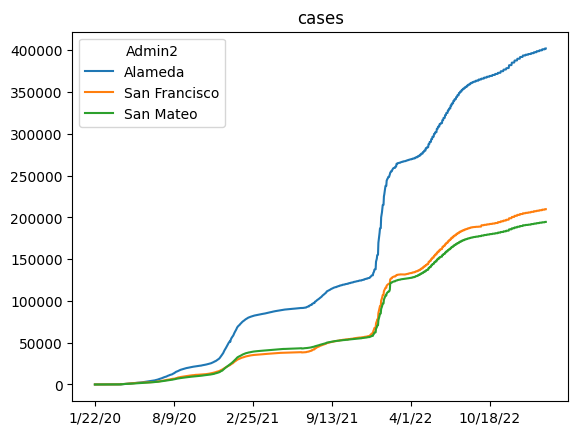

In [22]:
counties =['Alameda','San Francisco','San Mateo' ]
plot= cases_clean[counties].plot()
plot.set_title("cases")

Text(0.5, 1.0, 'deaths')

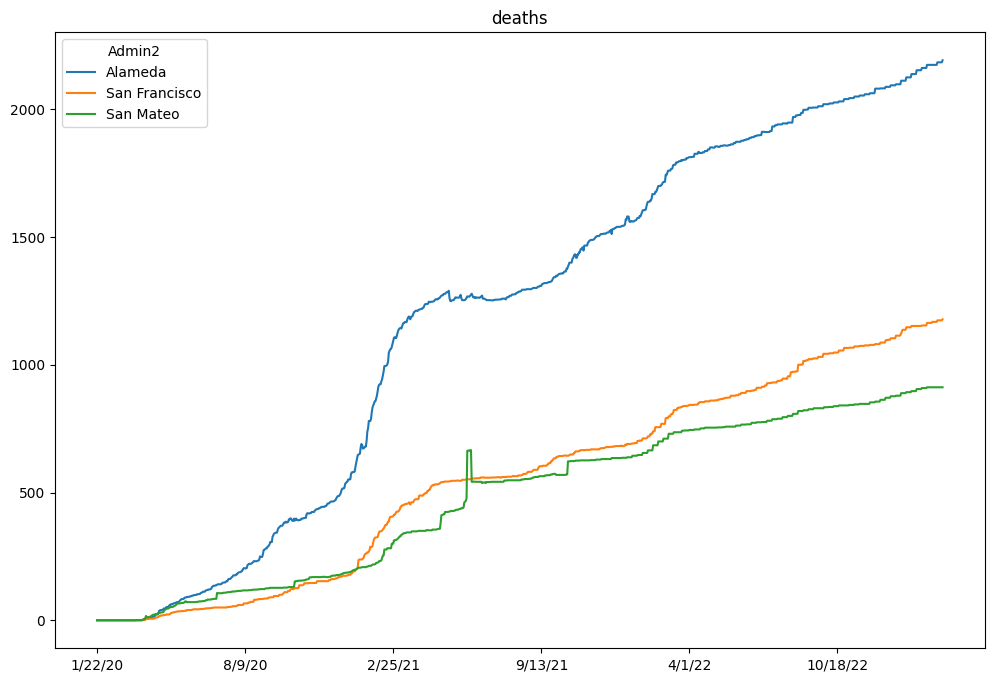

In [24]:
plot=deaths_clean[counties].plot(figsize=(12,8))
plot.set_title("deaths")

In [25]:
cases_diff = cases_clean.diff().rolling(window=7).mean()
deaths_diff = deaths_clean.diff().rolling(window=7).mean()

In [26]:
pop = pd.read_csv('https://gist.githubusercontent.com/NillsF/7923a8c7f27ca98ec75b7e1529f259bb/raw/3bedefbe2e242addba3fb47cbcd239fbed16cd54/california.csv')

In [27]:
pop["CTYNAME"] = pop["CTYNAME"].str.replace(" County", "")

In [28]:
pop

,CTYNAME,Pop,GrowthRate
0,Los Angeles,10105518,2.8820
1,San Diego,3343364,7.7356
2,Orange,3185968,5.6160
3,Riverside,2450758,11.3145
4,San Bernardino,2171603,6.4037
5,Santa Clara,1937570,8.4818
6,Alameda,1666753,10.1590
7,Sacramento,1540975,8.4114
8,Contra Costa,1150215,9.2780
9,Fresno,994400,6.6881


In [29]:
pop2 = pop.drop('GrowthRate', axis=1).set_index('CTYNAME')
pop2


,Pop
CTYNAME,
Los Angeles,10105518
San Diego,3343364
Orange,3185968
Riverside,2450758
San Bernardino,2171603
Santa Clara,1937570
Alameda,1666753
Sacramento,1540975
Contra Costa,1150215


In [30]:
cases_pm = cases_clean.copy()
for c in pop2.index.tolist():
    cases_pm[c] = cases_pm[c]/pop2.loc[c , : ]['Pop']
cases_pm = cases_pm*1000000

deaths_pm = deaths_clean.copy()
for c in pop2.index.tolist():
    deaths_pm[c] = deaths_pm[c]/pop2.loc[c , : ]['Pop']
deaths_pm = deaths_pm*1000000

In [31]:
cases_pm_diff = cases_pm.diff().rolling(window=7).mean()
deaths_pm_diff = deaths_pm.diff().rolling(window=7).mean()

Text(0.5, 1.0, 'avg 7 day cases ')

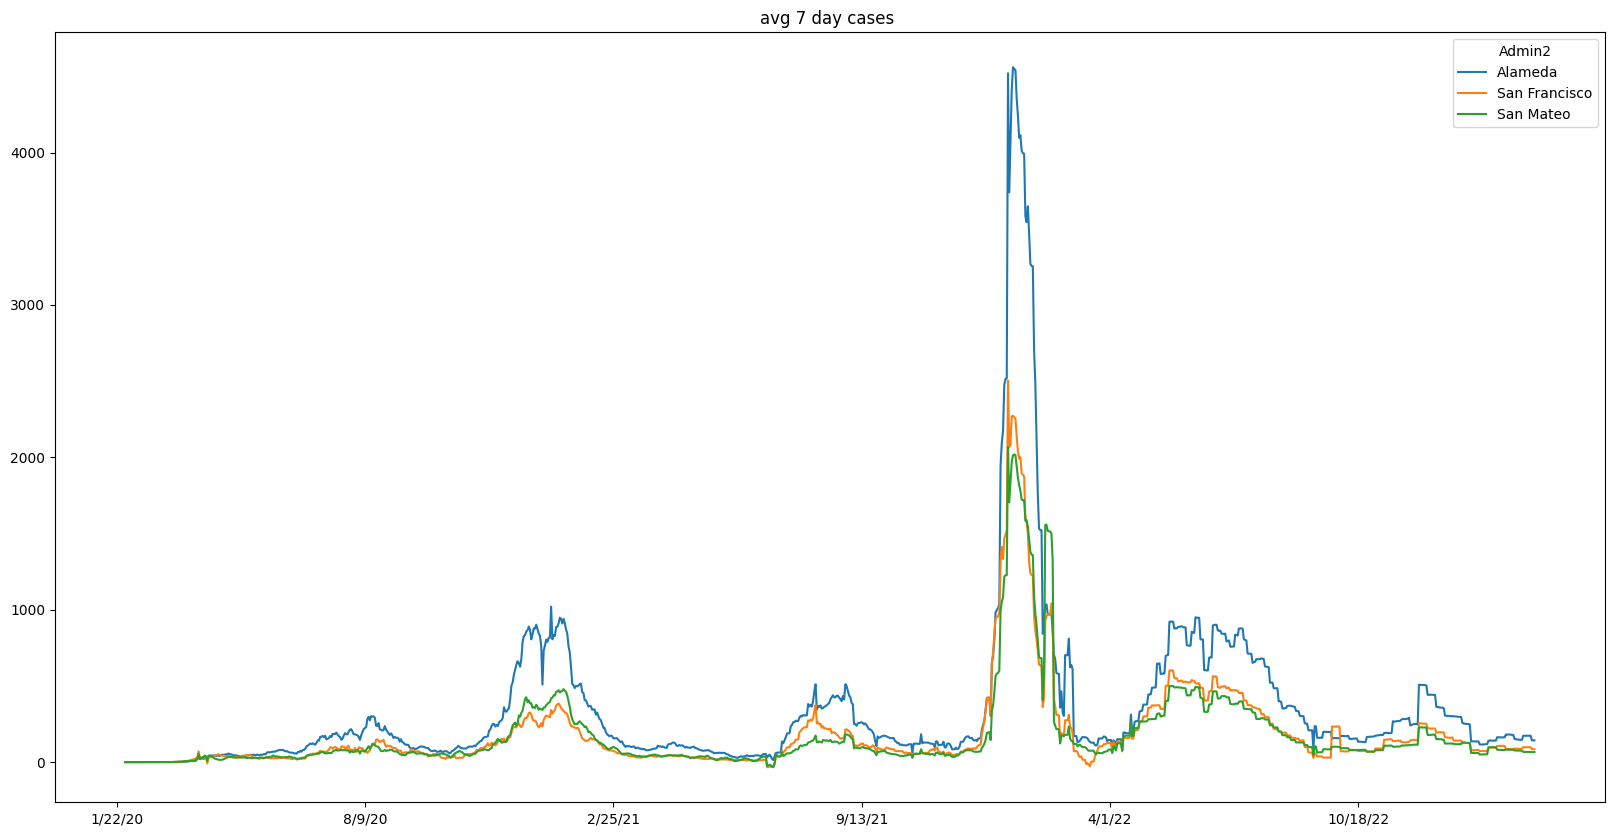

In [33]:
plot = cases_diff[counties].plot(figsize=(20,10))
plot.set_title("avg 7 day cases ")

Text(0.5, 1.0, 'new 7 day avg ')

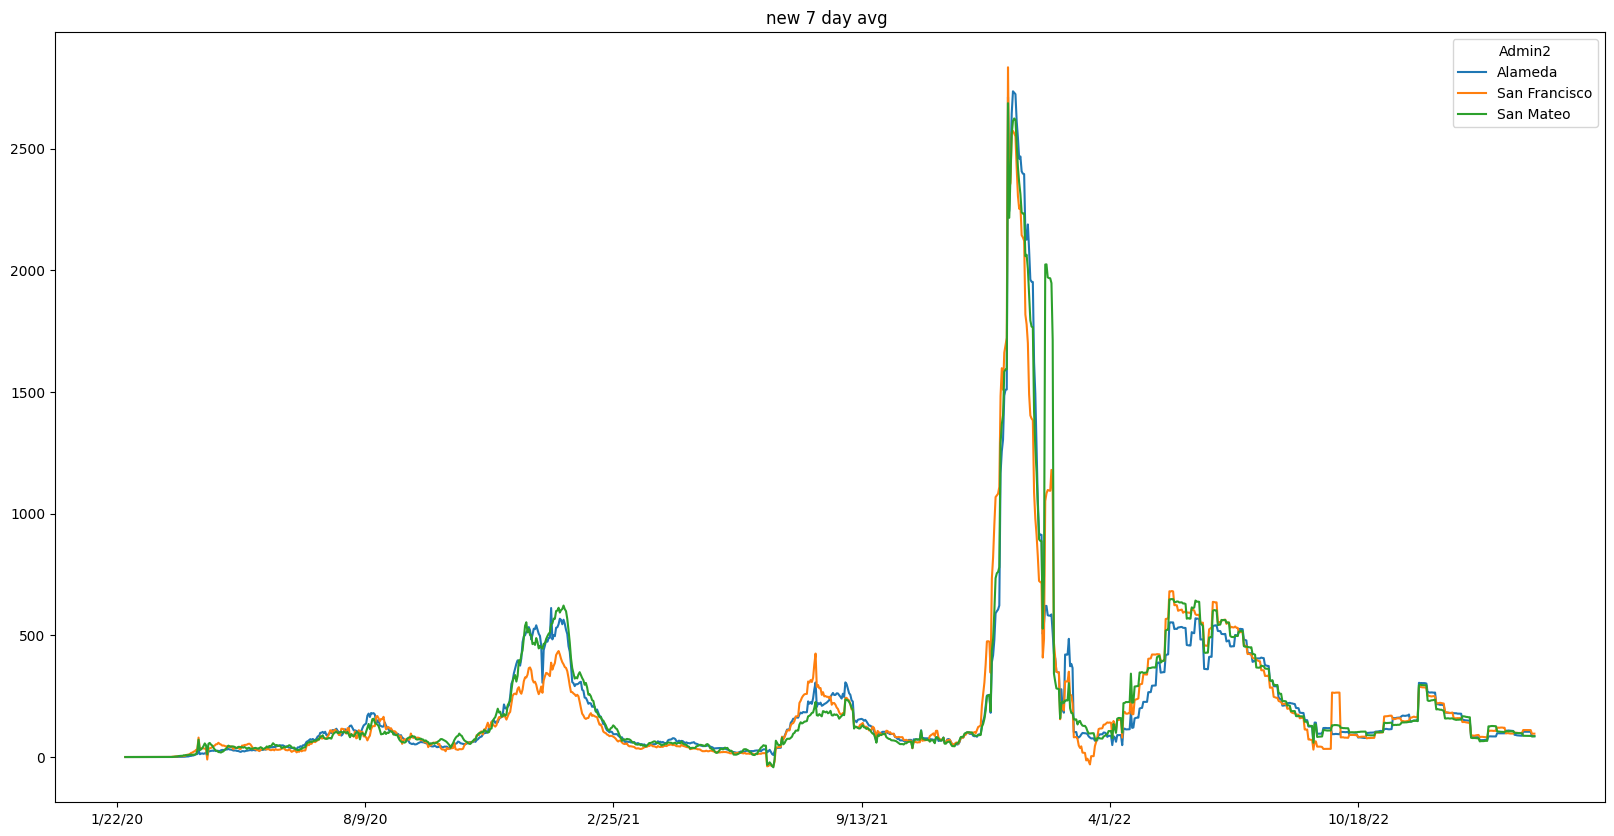

In [36]:
plot = cases_pm_diff[counties].plot(figsize=(20,10))
plot.set_title("new 7 day avg ")

Text(0.5, 1.0, 'Top 10 counties')

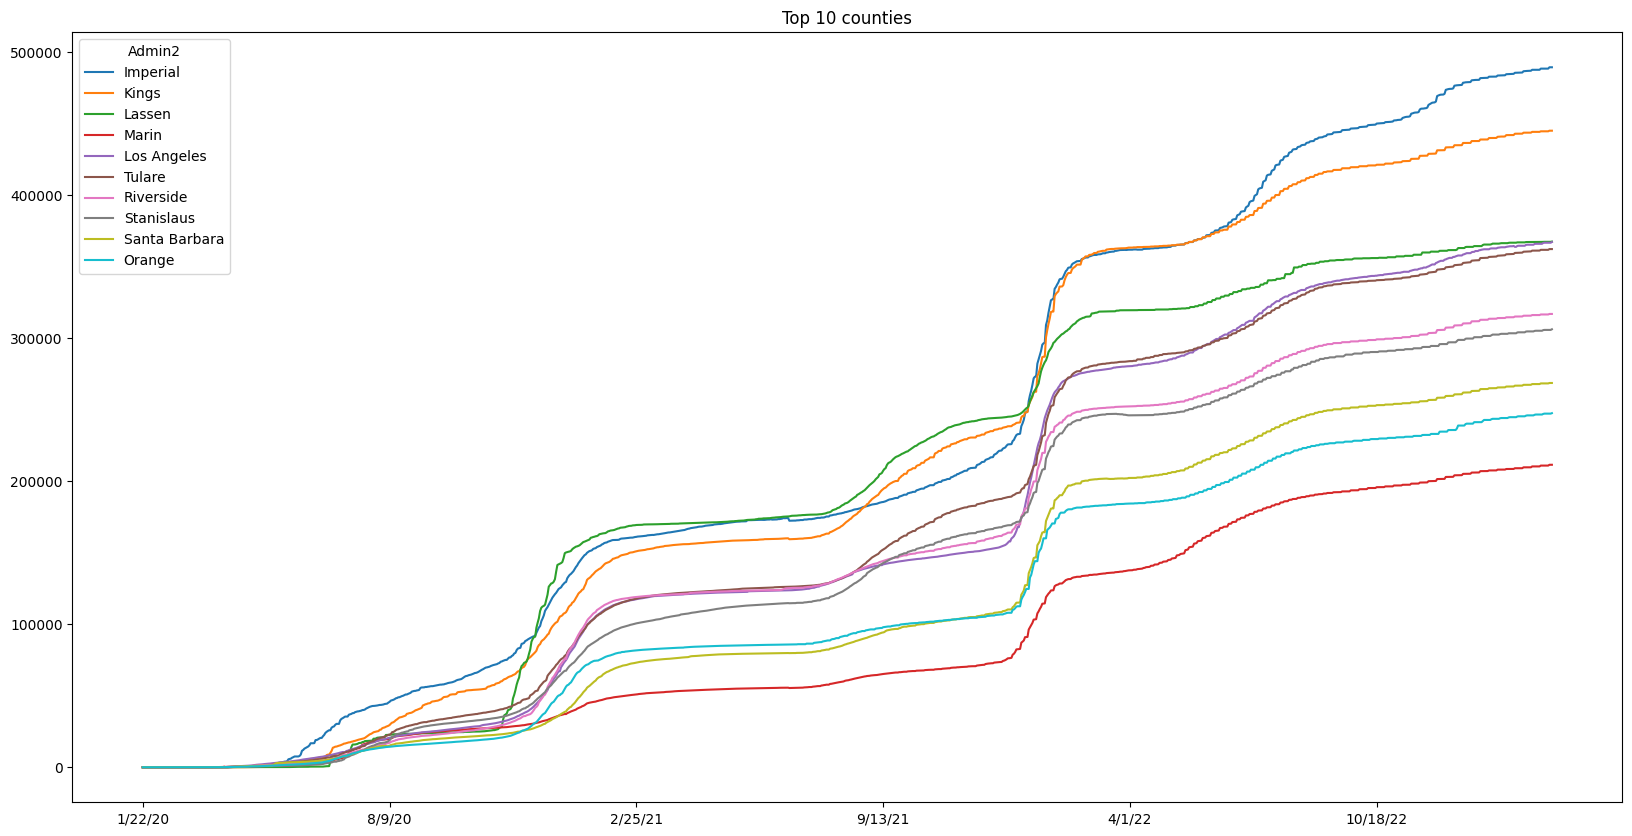

In [37]:
plot = cases_pm.sort_values(axis=1,by='7/20/20',ascending=False).iloc[: , : 10].plot(figsize=(20,10))
plot.set_title("Top 10 counties")


Text(0.5, 1.0, 'Top 10 counties deaths')

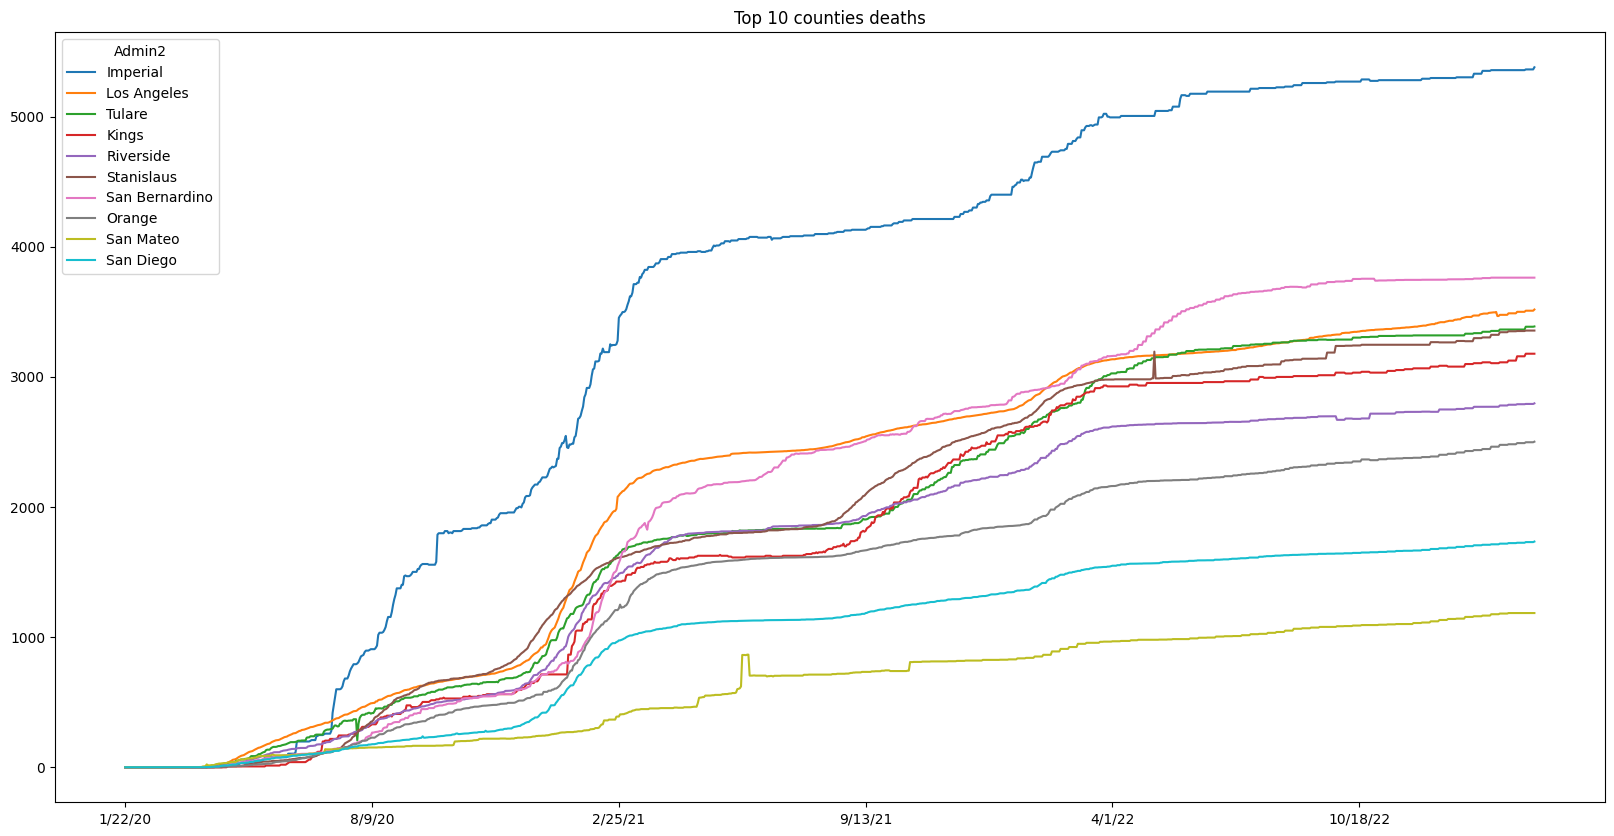

In [38]:
plot = deaths_pm.sort_values(axis=1,by='7/20/20',ascending=False).iloc[: , : 10].plot(figsize=(20,10))
plot.set_title("Top 10 counties deaths")

Text(0.5, 1.0, 'Top 10, 7 day rolling avg cases increases per million')

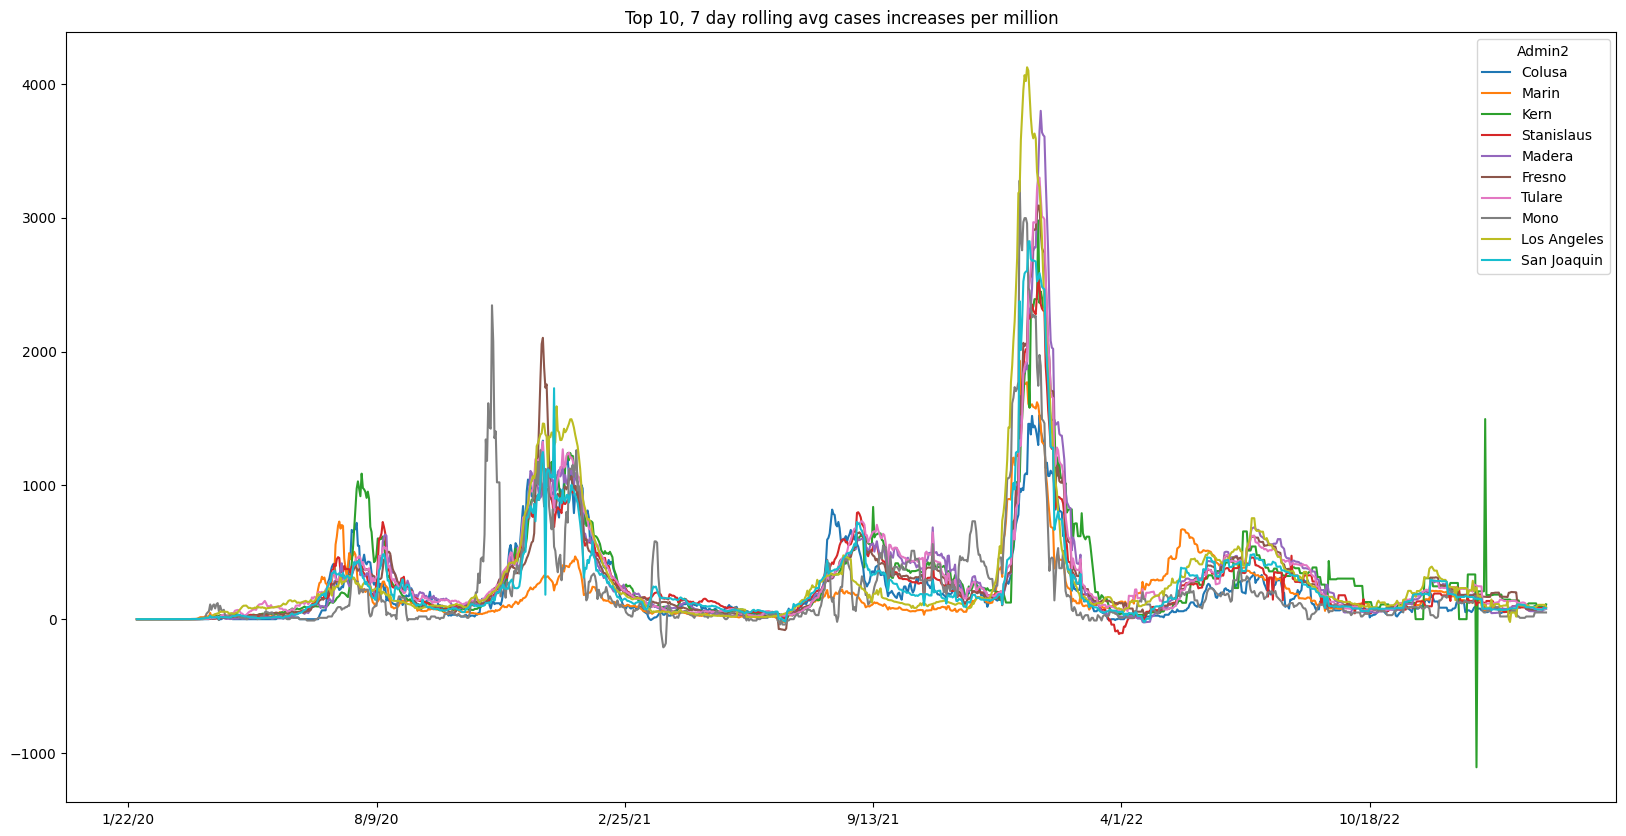

In [39]:
plot = cases_pm_diff.sort_values(axis=1,by='7/20/20',ascending=False).iloc[: , : 10].plot(figsize=(20,10))
plot.set_title("Top 10, 7 day rolling avg cases increases per million")

Text(0.5, 1.0, 'Top 10 counties by 7 day rolling avg daily deaths per million')

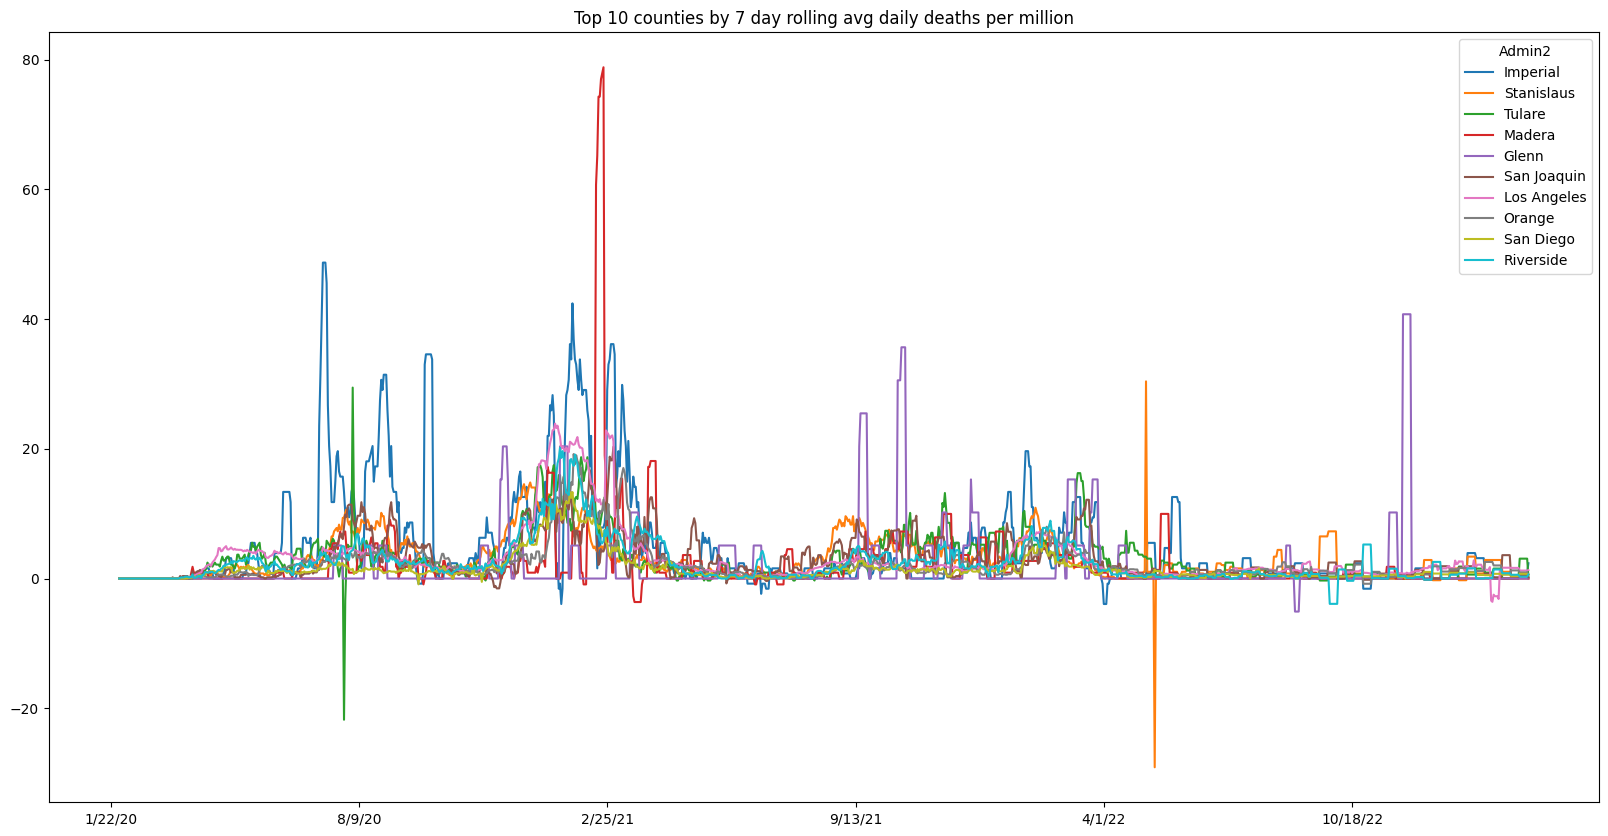

In [40]:
plot = deaths_pm_diff.sort_values(axis=1,by='7/20/20',ascending=False).iloc[: , : 10].plot(figsize=(20,10))
plot.set_title("Top 10 counties by 7 day rolling avg daily deaths per million")